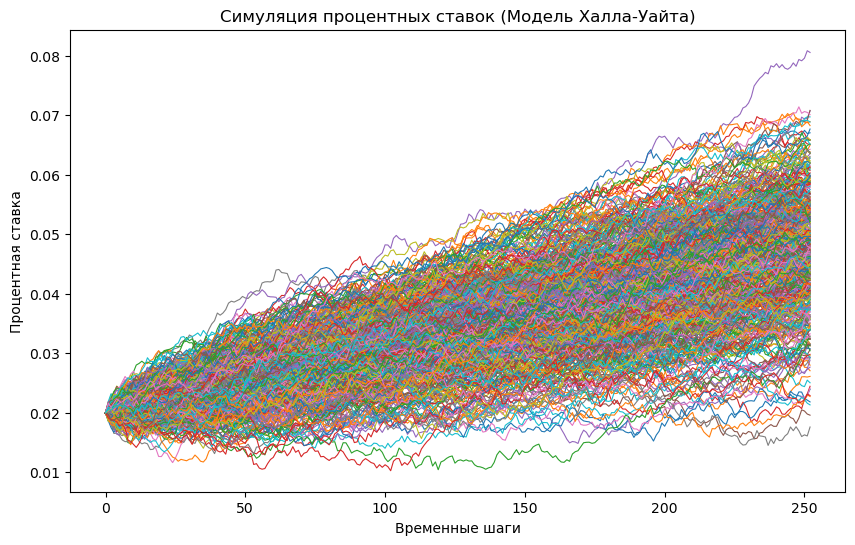

In [34]:
import torch
import matplotlib.pyplot as plt

def simulate_hull_white(r0, a, sigma, theta_t, T, n_steps, n_paths, device='cpu'):
    """
    Симулирует процесс Халла-Уайта, предполагая, что theta_t — это константа.

    Args:
        r0 (float): Начальная процентная ставка.
        a (float): Скорость возврата к среднему.
        sigma (float): Волатильность.
        theta_t (float): Долгосрочное среднее.
        T (float): Временной горизонт.
        n_steps (int): Количество временных шагов.
        n_paths (int): Количество симулированных траекторий.
        device (str): 'cpu' или 'cuda'.

    Returns:
        torch.Tensor: Тензор формы (n_paths, n_steps+1).
    """
    dt = torch.tensor(T / n_steps)
    # Инициализируем тензор для хранения всех траекторий
    rates = torch.zeros(n_paths, n_steps + 1, device=device)
    rates[:, 0] = r0

    # Генерируем все случайные шумы за один раз
    z = torch.randn(n_paths, n_steps, device=device)

    for t in range(1, n_steps + 1):
        r_prev = rates[:, t-1]
        # Дискретизация методом Эйлера-Маруямы
        dr = (theta_t - a * r_prev) * dt + sigma * torch.sqrt(dt) * z[:, t-1]
        rates[:, t] = r_prev + dr

    return rates

# Параметры модели
r0 = 0.02
a = 0.1
sigma = 0.01
theta_t = 0.03
T = 1.0
n_steps = 252
n_paths = 500
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Запуск симуляции
rates = simulate_hull_white(r0, a, sigma, theta_t, T, n_steps, n_paths, device)

# Визуализация
plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(rates[i].cpu().numpy(), lw=0.8)
plt.title("Симуляция процентных ставок (Модель Халла-Уайта)")
plt.xlabel("Временные шаги")
plt.ylabel("Процентная ставка")
plt.show()